(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


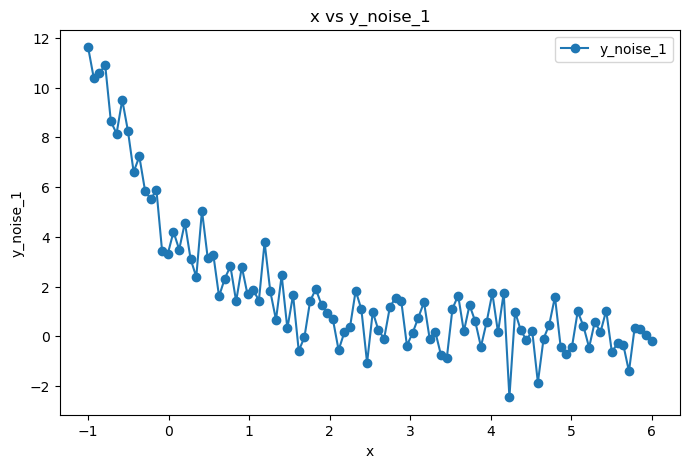

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv("noisy_curvefit_data.csv")
print(df.shape)
# 100 rows, 6 columns
print(df.head(5))
print(df.tail(5))
# Column names are: "x", "y_noise_1", "y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"
xvyn1 = df.plot(x = "x", y = "y_noise_1", kind = 'line', marker = 'o', figsize = (8,5), title = 'x vs y_noise_1')
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.legend()
plt.show()

Fit: y =  4.71 * e^(- 0.92 *x)


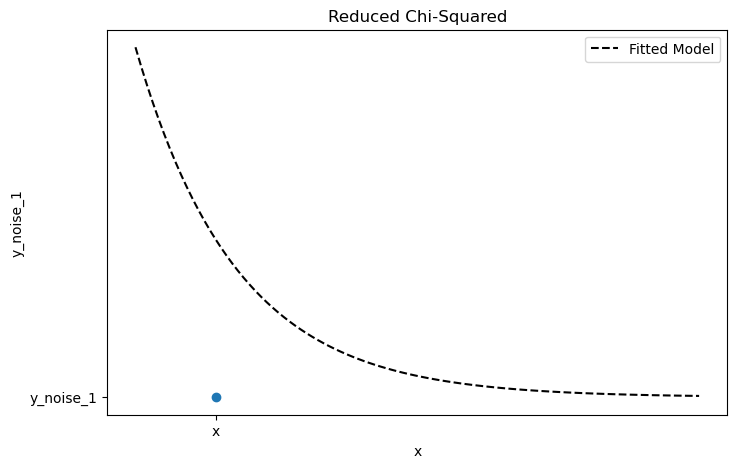

In [38]:
def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1,1]
popt, pcov = curve_fit(model, df['x'], df['y_noise_1'], p0 = p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit: .2f} * e^(-{k_fit: .2f} *x)")
#xvyn1 = df.plot(x = 'x', y = 'y_noise_1', kind = 'line', marker = 'o', figsize = (8,5), title = 'x vs y_noise_1')
residuals = df['y_noise_1'] - model(df['x'], A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(df['x']) - len(popt)
chi2_reduced = chi2 / dof
plt.figure(figsize = (8,5))
plt.scatter(x = 'x', y = 'y_noise_1')
y_fit = model(df['x'], 5, .8)
plt.plot(df['x'], y_fit, color = 'black', linestyle = '--', label = "Fitted Model")
plt.title("Reduced Chi-Squared")
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.legend()
plt.show()

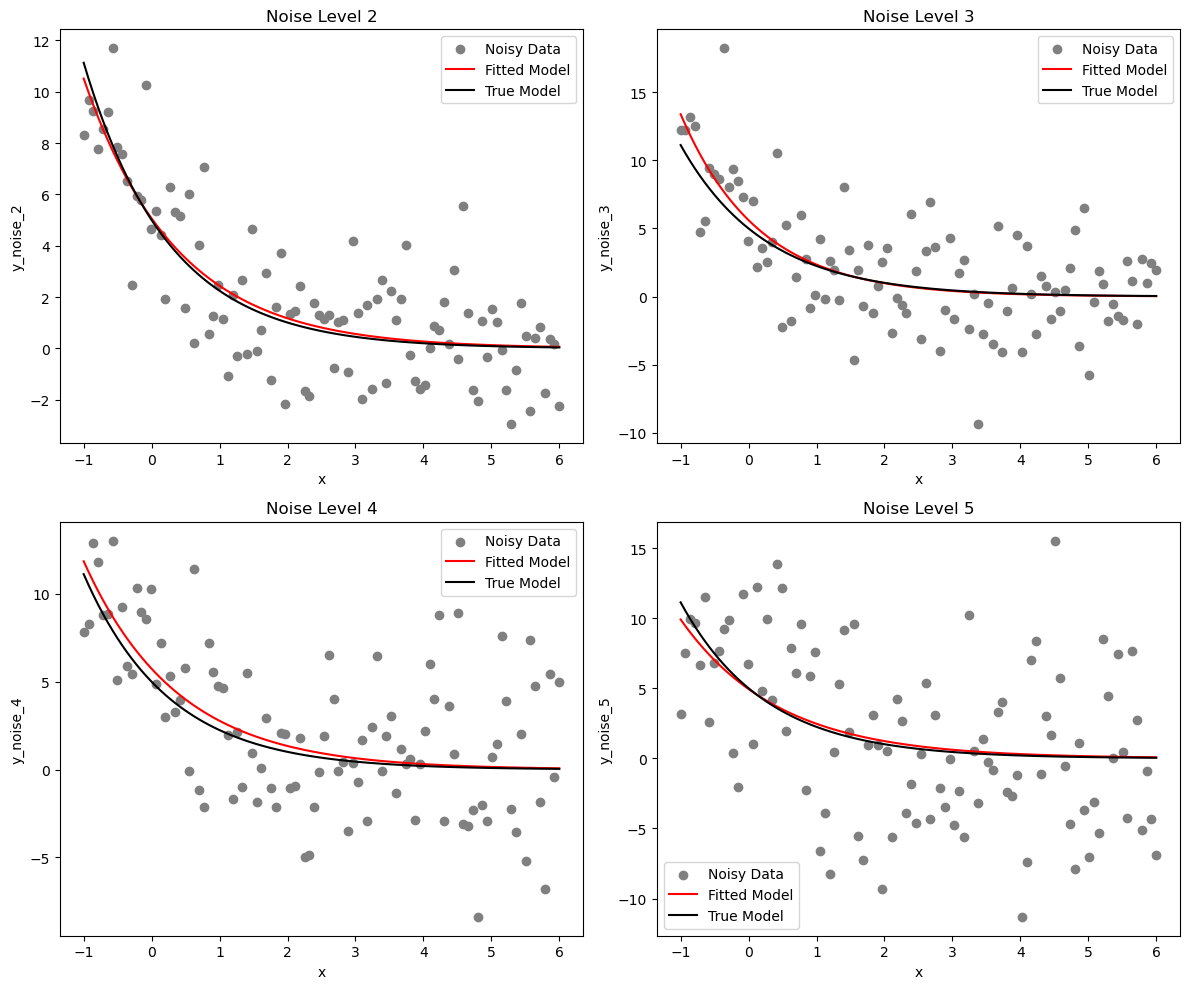

In [47]:
def fit_model(x,y):
    popt, pcov = curve_fit(model, x, y, p0 = [1,1])
    residuals = y - model(x, *popt)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced

fig, axes = plt.subplots(2,2, figsize = (12,10))
axes = axes.flatten()
noise_col = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

for i, col in enumerate(noise_col):
    ax = axes[i]
    popt, chi2_red = fit_model(df['x'], df[col])
    ax.scatter(df['x'], df[col], color = 'gray', label = 'Noisy Data')
    y_fit = model(df['x'], *popt)
    ax.plot(df['x'], y_fit, color = 'red', label = 'Fitted Model')
    y_true = model(df['x'], 5, .8)
    ax.plot(df['x'], y_true, color = 'black', label = 'True Model')
    noise_level = col.split('_')[-1]
    ax.set_title(f"Noise Level {noise_level}")
    ax.set_xlabel("x")
    ax.set_ylabel(col)
    ax.legend()
plt.tight_layout()
plt.show()
#As the noise level increases, the fitted model matches the true model less
#As the noise level increase, the chi-squared values become more scattered

In [51]:
noise_levels = []
A_fits = []
k_fits = []
chi2_reduced = []
noise_col = ['y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
for i, col in enumerate(noise_col):
    noise_level = i + 1
    popt, chi2 = fit_model(df['x'], df[col])
    noise_levels.append(noise_level)
    A_fits.append(popt[0])
    k_fits.append(popt[1])
    chi2_reduced.append(chi2)
df_results = pd.DataFrame({
    'Noise level': noise_levels,
    'A fit': A_fits,
    'k fit': k_fits,
    'Reduced chi-squared': chi2_reduced})
print(df_results)
df_results.to_csv("noisy_parameters.csv", index = False)

   Noise level     A fit     k fit  Reduced chi-squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124
